<a href="https://colab.research.google.com/github/marceloBilbyIA/ConfusionMatrix/blob/main/confusionmatrix_dio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

TensorFlow version: 2.17.1


In [ ]:
%load_ext tensorboard

In [ ]:
logdir='log'

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images / 255
test_images = test_images/ 255

classes=[0,1,2,3,4,5,6,7,8,9]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tensor_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(x=train_images, y=train_labels, epochs=5, validation_data=(test_images, test_labels), callbacks=[tensor_callback])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 37ms/step - accuracy: 0.6702 - loss: 1.4870 - val_accuracy: 0.8161 - val_loss: 0.8522
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.8306 - loss: 0.7766 - val_accuracy: 0.8378 - val_loss: 0.7574
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.8406 - loss: 0.7235 - val_accuracy: 0.8406 - val_loss: 0.7397
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.8479 - loss: 0.6898 - val_accuracy: 0.8474 - val_loss: 0.7026
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8657 - loss: 0.5753 - val_accuracy: 0.8950 - val_loss: 0.2910


In [ ]:
y_true = test_labels
y_pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [ ]:
con_mat = tf.math.confusion_matrix(y_true, np.argmax(y_pred, axis=1))
con_mat_norm = np.around(con_mat.numpy() / con_mat.numpy().sum(axis=1)[:, np.newaxis], decimals=2)
con_mat_df = pd.DataFrame(con_mat_norm,
                          index=classes,
                          columns=classes)

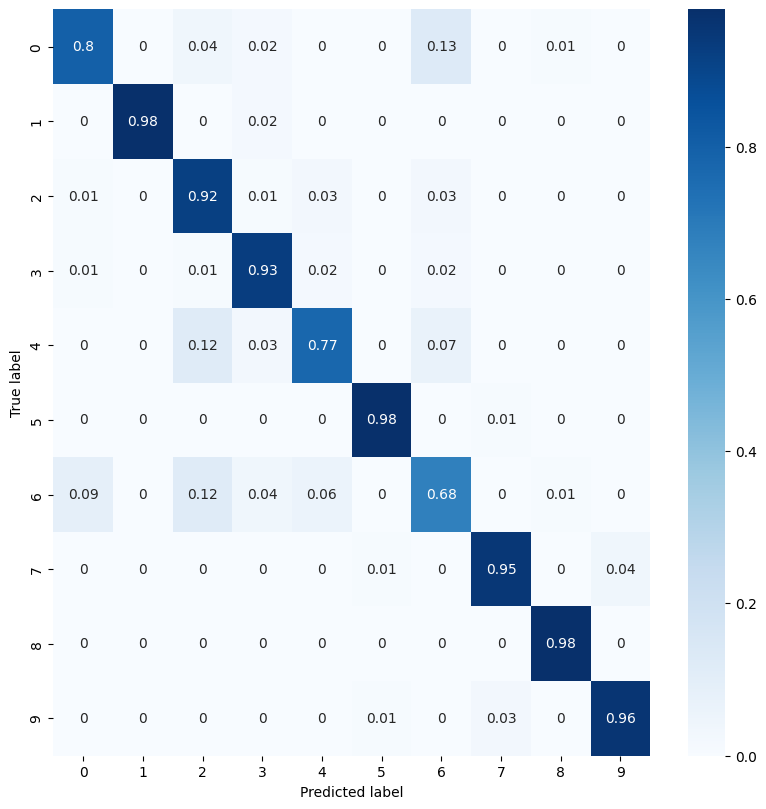

In [ ]:
figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
# Calculando a sensibilidade para cada classe
for i in range(len(con_mat_df)):
    VP = con_mat_df.iloc[i, i]  # Verdadeiros Positivos (diagonal principal)
    FN = sum(con_mat_df.iloc[i, :]) - VP  # Falsos Negativos (soma da linha - VP)
    sensibilidade = VP / (VP + FN) if (VP + FN) != 0 else 0
    print(f"Sensibilidade para a classe {i}: {sensibilidade*100:.2f}%")

Sensibilidade para a classe 0: 80.00%
Sensibilidade para a classe 1: 98.00%
Sensibilidade para a classe 2: 92.00%
Sensibilidade para a classe 3: 93.94%
Sensibilidade para a classe 4: 77.78%
Sensibilidade para a classe 5: 98.99%
Sensibilidade para a classe 6: 68.00%
Sensibilidade para a classe 7: 95.00%
Sensibilidade para a classe 8: 100.00%
Sensibilidade para a classe 9: 96.00%


In [ ]:
# Calculando a acurácia para cada classe

n = np.sum(con_mat_df)
#print(f"Total: {n}")
for i in range(len(con_mat_df)):
  VP = con_mat_df.iloc[i, i] # Verdadeiros Positivos (diagonal principal)
  #print(f"Verdadeiros Positivos: {VP}")
  FN = sum(con_mat_df.iloc[i, :]) - VP # Falsos Negativos (soma da linha - VP)
  #print(f"Falsos Negativos: {FN}")
  FP = sum(con_mat_df.iloc[:, i]) - VP # Falsos Positivos (soma da coluna - VP)
  #print(f"Falsos Positivos: {FP}")
  soma = (VP + FN + FP)
  #print(f"Soma: {soma}")
  VN = (n[i] - soma) # Verdadeiros Negativos (soma total - (VP + FN + FP)
  #print(f"Verdadeiros Negativos {i}: {VN}")
  acuracia = (VP + VN) / n[i]
  print(f"Acurácia para a classe {i}: {acuracia}")

Acurácia para a classe 0: 0.6593406593406596
Acurácia para a classe 1: 0.9795918367346939
Acurácia para a classe 2: 0.6942148760330579
Acurácia para a classe 3: 0.8285714285714285
Acurácia para a classe 4: 0.625
Acurácia para a classe 5: 0.97
Acurácia para a classe 6: 0.3870967741935485
Acurácia para a classe 7: 0.9090909090909091
Acurácia para a classe 8: 0.98
Acurácia para a classe 9: 0.9199999999999999


In [ ]:
# Calculo da Especificidade
for i in range(len(con_mat_df)):
  VP = con_mat_df.iloc[i, i] # Verdadeiros Positivos (diagonal principal)
  #print(f"Verdadeiros Positivos: {VP}")
  FN = sum(con_mat_df.iloc[i, :]) - VP # Falsos Negativos (soma da linha - VP)
  #print(f"Falsos Negativos: {FN}")
  FP = sum(con_mat_df.iloc[:, i]) - VP # Falsos Positivos (soma da coluna - VP)
  #print(f"Falsos Positivos: {FP}")
  soma = (VP + FN + FP)
  #print(f"Soma: {soma}")
  VN = (n[i] - soma) # Verdadeiros Negativos (soma total - (VP + FN + FP)
  #print(f"Verdadeiros Negativos {i}: {VN}")
  especificidade = VN / (VN + FP) if (VN + FP) != 0 else 0.0
  print(f"Especificidade para a classe {i}: {especificidade}")


Especificidade para a classe 0: 2.222222222222224
Especificidade para a classe 1: 1.0
Especificidade para a classe 2: -0.38095238095238154
Especificidade para a classe 3: -1.0000000000000018
Especificidade para a classe 4: 2.000000000000002
Especificidade para a classe 5: -1.0
Especificidade para a classe 6: 4.571428571428574
Especificidade para a classe 7: 5.0
Especificidade para a classe 8: 0.0
Especificidade para a classe 9: 0.0


In [ ]:
# Calculo da precisão
for i in range(len(con_mat_df)):
  VP = con_mat_df.iloc[i, i] # Verdadeiros Positivos (diagonal principal)
  #print(f"Verdadeiros Positivos: {VP}")
  FN = sum(con_mat_df.iloc[i, :]) - VP # Falsos Negativos (soma da linha - VP)
  #print(f"Falsos Negativos: {FN}")
  FP = sum(con_mat_df.iloc[:, i]) - VP # Falsos Positivos (soma da coluna - VP)
  #print(f"Falsos Positivos: {FP}")
  soma = (VP + FN + FP)
  #print(f"Soma: {soma}")
  VN = (n[i] - soma) # Verdadeiros Negativos (soma total - (VP + FN + FP)
  #print(f"Verdadeiros Negativos {i}: {VN}")
  precisao = VP / (VP + FP) if (VP + FP) != 0 else 0.0
  print(f"Especificidade para a classe {i}: {precisao}")


Especificidade para a classe 0: 0.8791208791208791
Especificidade para a classe 1: 1.0
Especificidade para a classe 2: 0.7603305785123967
Especificidade para a classe 3: 0.8857142857142857
Especificidade para a classe 4: 0.8749999999999999
Especificidade para a classe 5: 0.98
Especificidade para a classe 6: 0.7311827956989247
Especificidade para a classe 7: 0.9595959595959596
Especificidade para a classe 8: 0.98
Especificidade para a classe 9: 0.96


In [ ]:
# Calculo F-Score
# Calculo da precisão
for i in range(len(con_mat_df)):
  VP = con_mat_df.iloc[i, i] # Verdadeiros Positivos (diagonal principal)
  #print(f"Verdadeiros Positivos: {VP}")
  FN = sum(con_mat_df.iloc[i, :]) - VP # Falsos Negativos (soma da linha - VP)
  #print(f"Falsos Negativos: {FN}")
  FP = sum(con_mat_df.iloc[:, i]) - VP # Falsos Positivos (soma da coluna - VP)
  #print(f"Falsos Positivos: {FP}")
  soma = (VP + FN + FP)
  #print(f"Soma: {soma}")
  VN = (n[i] - soma) # Verdadeiros Negativos (soma total - (VP + FN + FP)
  #print(f"Verdadeiros Negativos {i}: {VN}")
  precisao = VP / (VP + FP) if (VP + FP) != 0 else 0.0
  especificidade = VN / (VN + FP) if (VN + FP) != 0 else 0.0
  f_score = 2 * (precisao * especificidade) / (precisao + especificidade)
  print(f"Especificidade para a classe {i}: {f_score}")

Especificidade para a classe 0: 1.2598425196850398
Especificidade para a classe 1: 1.0
Especificidade para a classe 2: -1.526970954356851
Especificidade para a classe 3: 15.49999999999978
Especificidade para a classe 4: 1.2173913043478264
Especificidade para a classe 5: 97.99999999999991
Especificidade para a classe 6: 1.2607184241019698
Especificidade para a classe 7: 1.6101694915254237
Especificidade para a classe 8: 0.0
Especificidade para a classe 9: 0.0
